# Лабораторная работа по курсу "Киберфизические системы" № 1

### 1. Выбор начальных условий

#### 1a. Обоснование выбора набора данных RDD-2022
Набор данных RDD-2022 предназначен для автоматического обнаружения дефектов дорожного покрытия.
Выбор данного датасета обусловлен решением реальной практической задачи мониторинга состояния
дорожной инфраструктуры. Датасет содержит изображения с 5 типами дефектов:

1. longitudinal crack (продольная трещина)

2. transverse crack (поперечная трещина)

3. alligator crack (трещина «аллигатор»/сетчатая)

4. other corruption (прочие дефекты)
5. Pothole (выбоина)

Наличие разнообразных классов и данных, собранных в разных условиях, позволяет обучить модель, устойчивую к реальным эксплуатационным факторам, и использовать её для автоматизации процесса инспекции дорог.

#### 1b. Обоснование выбора метрик качества
Для задачи обнаружения объектов (object detection) выбраны следующие метрики:
mAP@0.5 (mean Average Precision при IoU=0.5) — стандартная метрика, оценивающая точность локализации и классификации объектов при пороге пересечения bounding box равном 0.5. Позволяет получить общее представление о качестве детекции.

mAP@0.5:0.95 — усреднение mAP по порогам IoU от 0.5 до 0.95 с шагом 0.05. Отражает устойчивость модели к точному позиционированию границ объектов, что критично для последующей оценки площади и серьёзности дефектов.

Precision, Recall, F1-score — метрики, необходимые для анализа баланса между ложными срабатываниями (Precision) и пропущенными объектами (Recall). В контексте дорожной инспекции пропуск дефекта (низкий Recall) несёт большие риски для безопасности, чем ложное срабатывание, поэтому данные метрики являются ключевыми для оценки операционной пригодности модели.

In [1]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")

PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 2060 SUPER
CUDA version: 13.0


### 2. Создание бейзлайна и оценка качества

In [ ]:
from ultralytics import YOLO
import yaml
import pandas as pd
from pathlib import Path

DATA_CONFIG = "./data.yaml"
MODEL_NAME = "yolo11n.pt"
PROJECT_DIR = "test1"
EXP_NAME = "baseline_yolo11n"

print(f"Проверка путей: {Path(DATA_CONFIG).absolute()}")

print(f"\nИнициализация модели: {MODEL_NAME}")
model = YOLO(MODEL_NAME)

print("\nНачинаем обучение (Baseline)...")
results = model.train(
    data=DATA_CONFIG,
    epochs=10,
    imgsz=640,
    batch=16,      
    seed=42,       
    project=PROJECT_DIR,
    name=EXP_NAME,
    verbose=True,
    save=True,
    save_period=10 
)

print("\nЗапуск валидации (Оценка метрик)...")
metrics = model.val()

metric_dict = {
    "mAP@0.5": round(float(metrics.box.map50), 4),
    "mAP@0.5:0.95": round(float(metrics.box.map), 4),
    "Precision": round(float(metrics.box.p.mean()), 4),
    "Recall": round(float(metrics.box.r.mean()), 4),
    "F1-Score": round(float(metrics.box.f1.mean()), 4)
}

print("\n" + "="*40)
print("РЕЗУЛЬТАТЫ БАЗОВОЙ МОДЕЛИ")
print("="*40)
for k, v in metric_dict.items():
    print(f"{k:12} : {v}")
print("="*40)

df_metrics = pd.DataFrame([metric_dict])
df_metrics.to_csv("baseline_metrics.csv", index=False)
print(f"\nМетрики сохранены в: baseline_metrics.csv")
print(f"Веса модели: {PROJECT_DIR}/{EXP_NAME}/weights/best.pt")

Проверка путей: c:\Users\JonAJ\Desktop\RDD2022\RoadDamageDetection\data.yaml

Инициализация модели: yolo11n.pt

Начинаем обучение (Baseline)...
New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.40  Python-3.10.18 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=N

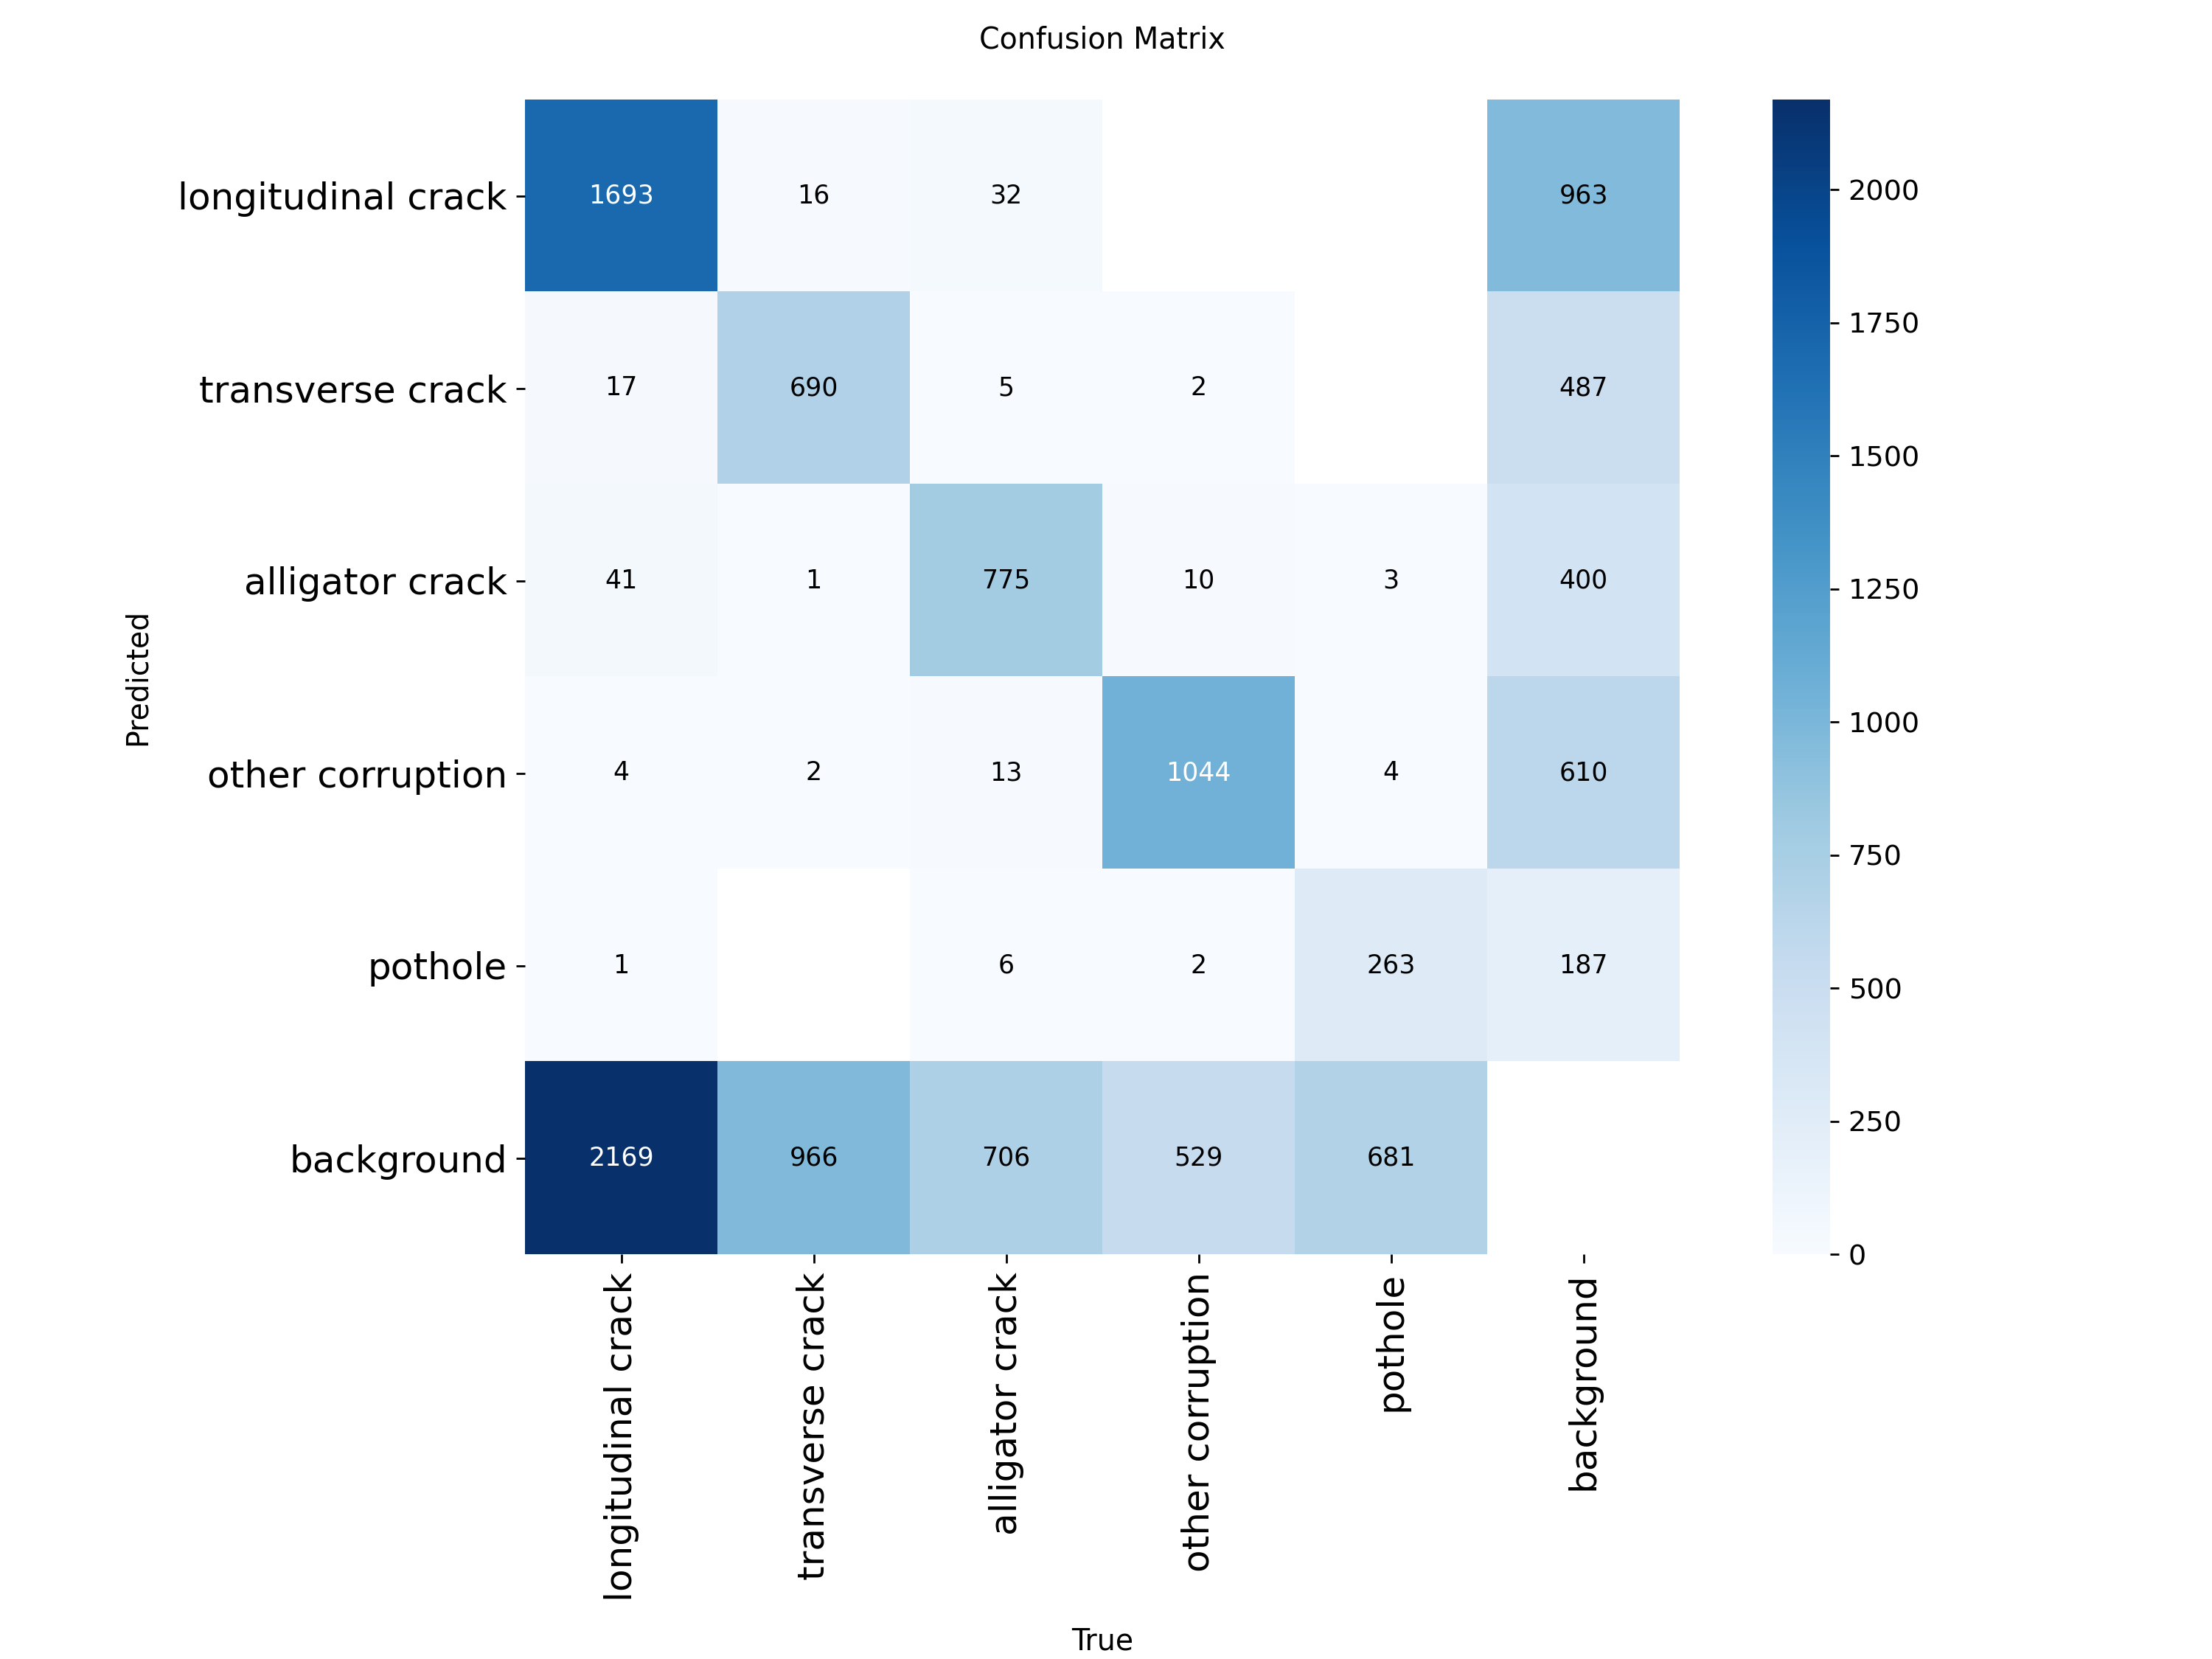

In [2]:
print("\n" + "="*50)
print("Финальная оценка на TEST наборе...")
print("="*50)

test_metrics = model.val(split='test', save_json=False, verbose=False)

test_map50 = float(test_metrics.box.map50)
test_map50_95 = float(test_metrics.box.map)
test_prec = float(test_metrics.box.p.mean())
test_rec = float(test_metrics.box.r.mean())
test_f1 = float(test_metrics.box.f1.mean())

print(f"\nРезультаты:")
print(f"mAP@0.5     : {test_map50:.4f}")
print(f"mAP@0.5:0.95: {test_map50_95:.4f}")
print(f"Precision   : {test_prec:.4f}")
print(f"Recall      : {test_rec:.4f}")
print(f"F1-Score    : {test_f1:.4f}")

test_results = {
    "model": "YOLOv11n",
    "dataset": "RDD-2022",
    "split": "test",
    "metrics": {
        "mAP@0.5": round(test_map50, 4),
        "mAP@0.5:0.95": round(test_map50_95, 4),
        "Precision": round(test_prec, 4),
        "Recall": round(test_rec, 4),
        "F1": round(test_f1, 4)
    }
}

with open("test_metrics.yaml", "w", encoding='utf-8') as f:
    yaml.dump(test_results, f, allow_unicode=True, default_flow_style=False)

print(f"\nТестовые метрики сохранены в: baseline_test_metrics.yaml")


Финальная оценка на TEST наборе...
Ultralytics 8.4.40  Python-3.10.18 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 414.6360.5 MB/s, size: 528.2 KB)
val: Scanning C:\Users\JonAJ\Desktop\RDD2022\RoadDamageDetection\RDD_SPLIT\test\labels.cache... 5758 images, 1790 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5758/5758  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 360/360 7.3it/s 49.5s<0.1s
                   all       5758       9675      0.554      0.471      0.485      0.247
Speed: 1.2ms preprocess, 3.4ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to C:\Users\JonAJ\Desktop\RDD2022\RoadDamageDetection\runs\detect\val-6

Результаты:
mAP@0.5     : 0.4847
mAP@0.5:0.95: 0.2471
Precision   : 0.5544
Recall      : 0.4712
F1-Score    : 0.5037

Тестовые метрики сохранены в: baseline_test_metrics.yaml


#### Выводы:

В результате обучения модели yolo11n на выбранном наборе данных с простым бейзлайном были получены метрики, оставляющие пространство для улучшения.


|Результаты:  |       |
|-------------|-------|
|mAP@0.5      | 0.4847|
|mAP@0.5:0.95 | 0.2471|
|Precision    | 0.5544|
|Recall       | 0.4712|
|F1-Score     | 0.5037|

### 3. Улучшение бейзлайна


Гипотезы:

H1 (Аугментации): Умеренные аугментации с фокусом на цвет и масштаб улучшат обобщение
   - Обоснование: Дефекты дорог снимаются в разных погодных условиях (hsv)
   - Разные камеры дают разный масштаб (scale)
   - Повороты (degrees) и вертикальные отражения (flipud) не нужны

H2 (Оптимизация обучения): Увеличение эпох и настройка LR улучшит сходимость
   - Обоснование: 10 эпох может быть недостаточно для полной сходимости

In [ ]:
from ultralytics import YOLO
import pandas as pd
from pathlib import Path

DATA_CONFIG = "./data.yaml"
MODEL_NAME = "yolo11n.pt"
PROJECT_DIR = "test1"
EXP_NAME_IMPROVED = "improved_baseline_yolo11n"

print(f"Проверка путей: {Path(DATA_CONFIG).absolute()}")

print(f"\nИнициализация модели: {MODEL_NAME}")
model = YOLO(MODEL_NAME)

print("\nНачинаем обучение (Baseline)...")
results = model.train(
    data=DATA_CONFIG,
    epochs=15,                    # H2
    imgsz=640,
    batch=16,
    seed=42,
    
    # H2: Оптимизация обучения
    optimizer='SGD',             
    lr0=0.005,                    
    lrf=0.01,                     
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3.0,
    
    # H1: Аугментации
    mosaic=1.0,                   
    mixup=0.0,                    
    degrees=0.0,                  
    translate=0.1,                
    scale=0.5,                    
    flipud=0.0,                   
    fliplr=0.5,                   
    hsv_h=0.015,                  
    hsv_s=0.7,                    
    hsv_v=0.4,                    
    
    # Управление обучением
    patience=10,                  
    save=True,
    save_period=5,  
    val=True,
    project=PROJECT_DIR,
    name=EXP_NAME_IMPROVED,
    exist_ok=True,
    pretrained=True,
    verbose=True,
    workers=4,
    amp=True,
)

print("\nЗапуск валидации (Оценка метрик)...")
metrics = model.val()

metric_dict = {
    "mAP@0.5": round(float(metrics.box.map50), 4),
    "mAP@0.5:0.95": round(float(metrics.box.map), 4),
    "Precision": round(float(metrics.box.p.mean()), 4),
    "Recall": round(float(metrics.box.r.mean()), 4),
    "F1-Score": round(float(metrics.box.f1.mean()), 4)
}

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ БАЗОВОЙ МОДЕЛИ")
print("="*50)
for k, v in metric_dict.items():
    print(f"{k:12} : {v}")
print("="*50)

df_metrics = pd.DataFrame([metric_dict])
df_metrics.to_csv("improved_baseline_metrics.csv", index=False)
print(f"\nМетрики сохранены в: improved_baseline_metrics.csv")
print(f"Веса модели: {PROJECT_DIR}/{EXP_NAME_IMPROVED}/weights/best.pt")

Проверка путей: c:\Users\JonAJ\Desktop\RDD2022\RoadDamageDetection\data.yaml

Инициализация модели: yolo11n.pt

Начинаем обучение (Baseline)...
New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.40  Python-3.10.18 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=No

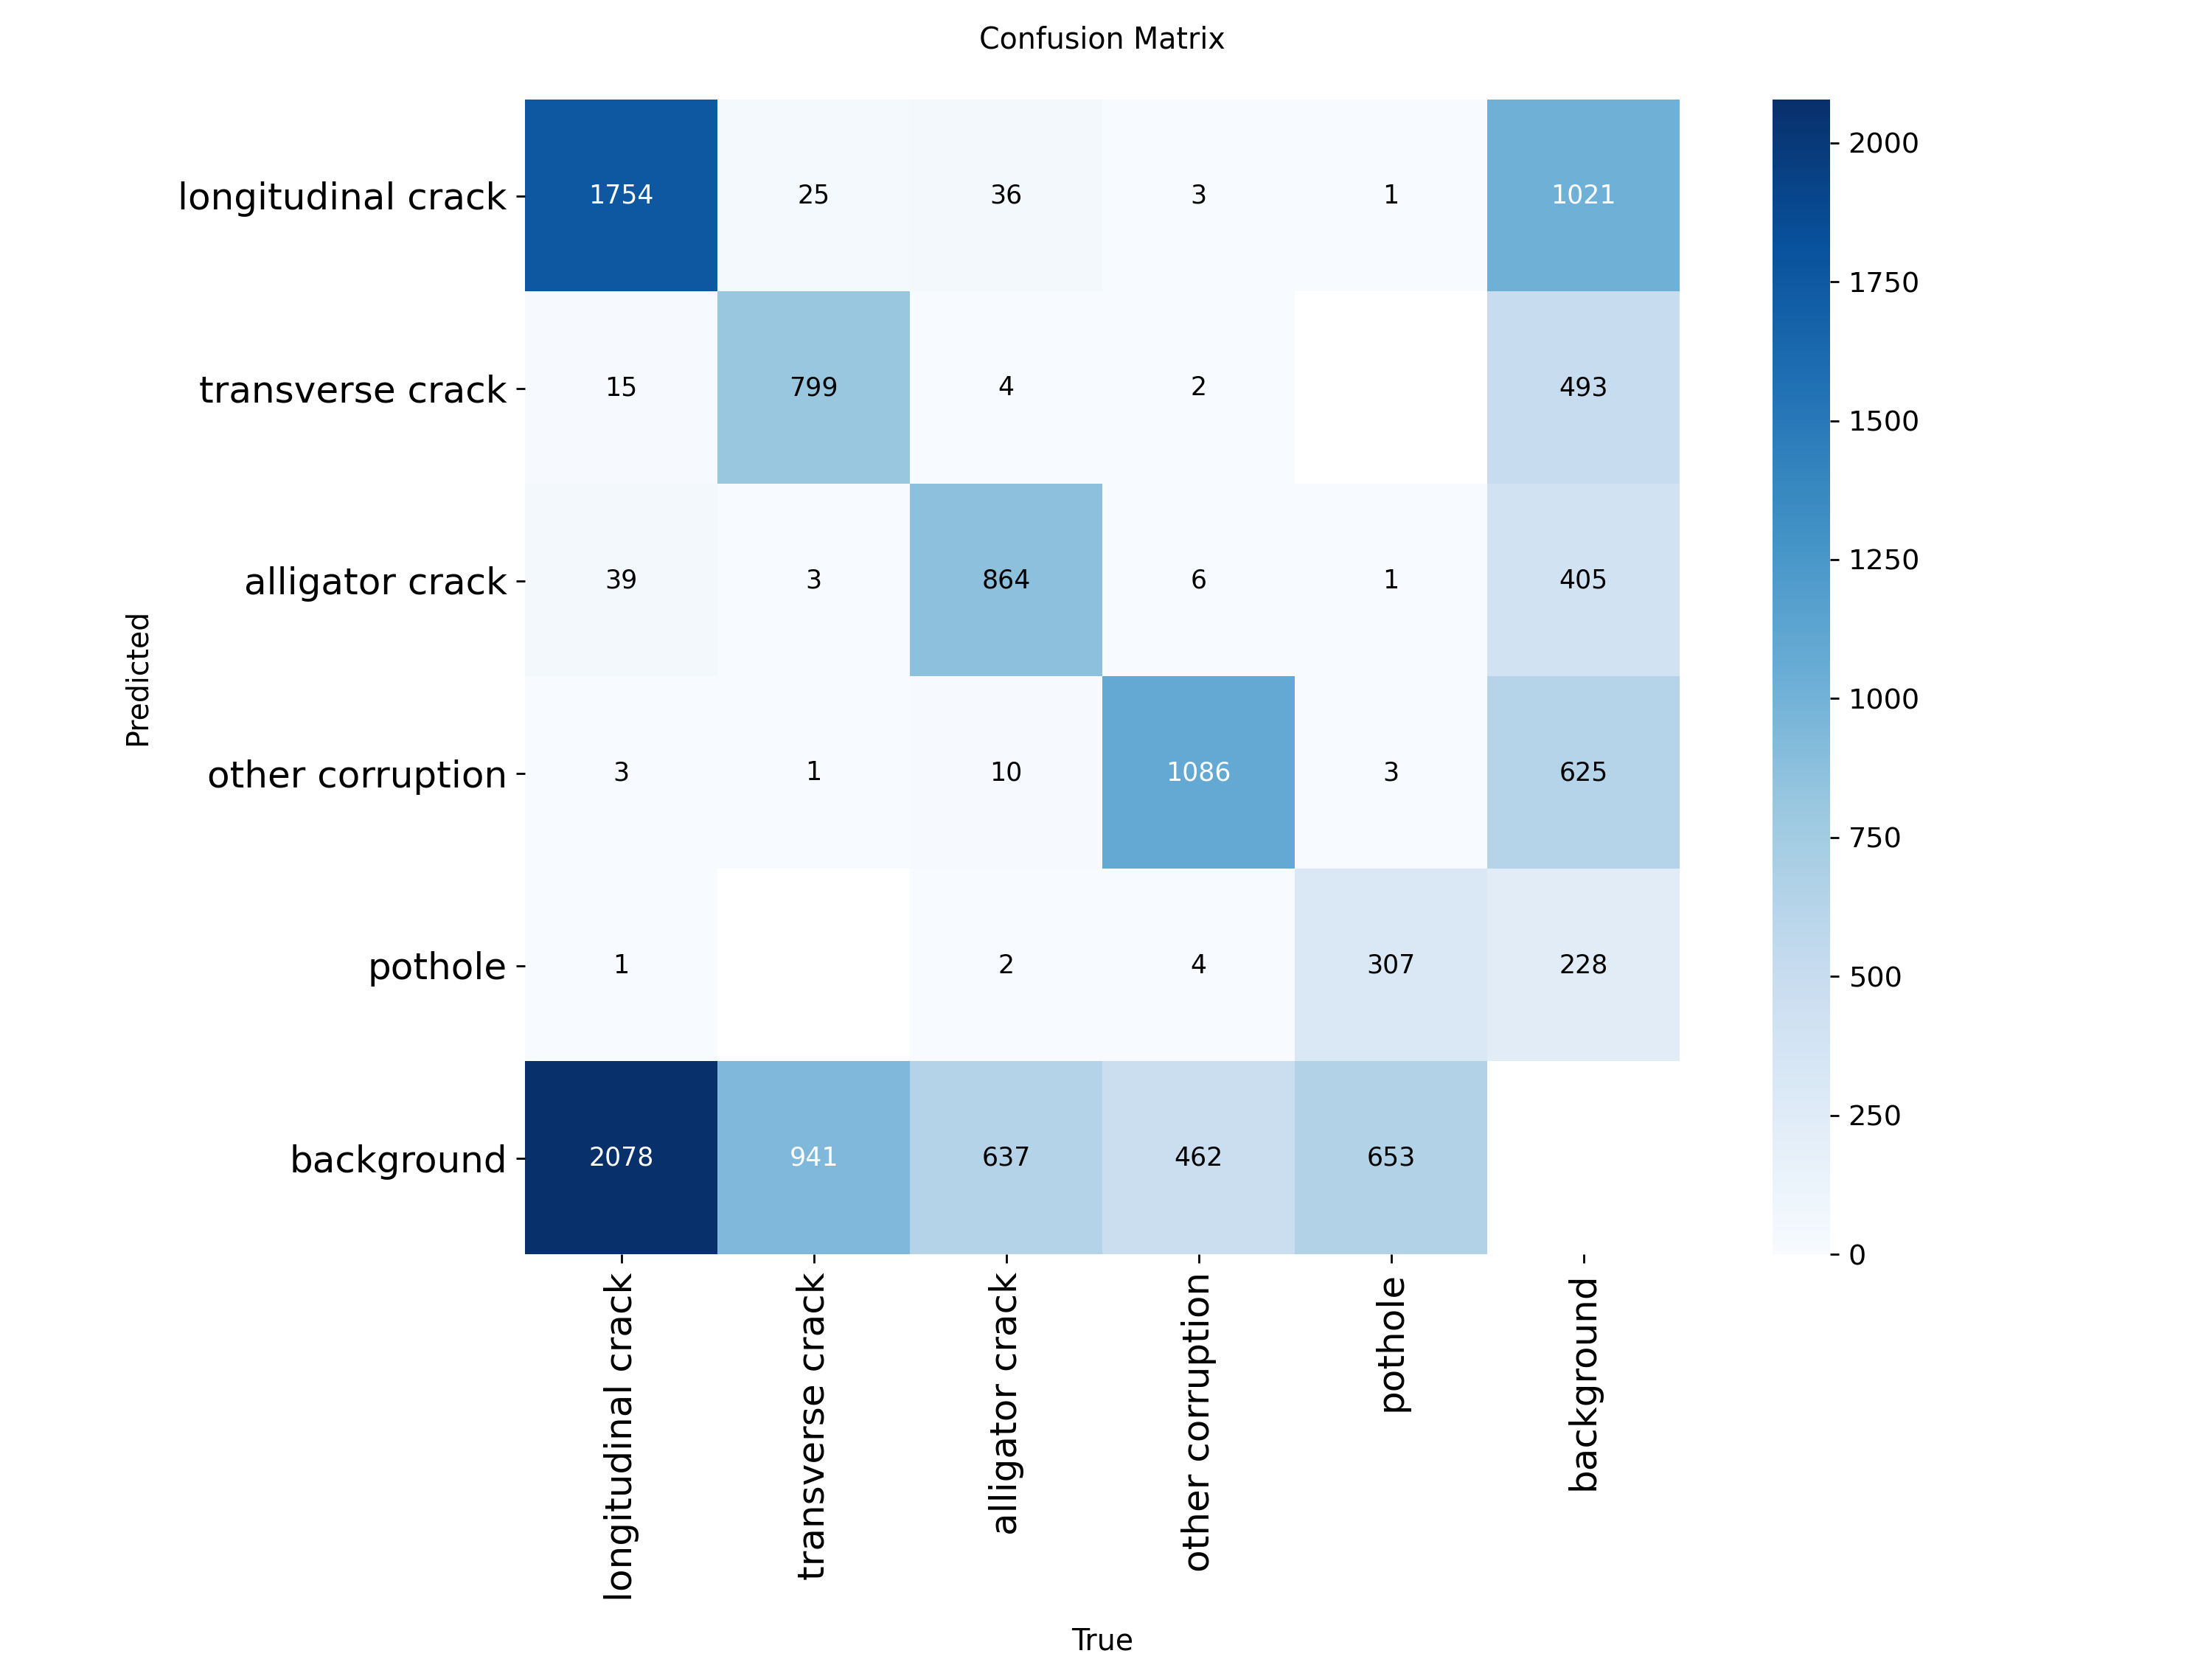

In [7]:
print("\n" + "="*50)
print("Финальная оценка на TEST наборе...")
print("="*50)

test_metrics = model.val(split='test', save_json=False, verbose=False)

test_map50 = float(test_metrics.box.map50)
test_map50_95 = float(test_metrics.box.map)
test_prec = float(test_metrics.box.p.mean())
test_rec = float(test_metrics.box.r.mean())
test_f1 = float(test_metrics.box.f1.mean())

print(f"\nРезультаты:")
print(f"mAP@0.5     : {test_map50:.4f}")
print(f"mAP@0.5:0.95: {test_map50_95:.4f}")
print(f"Precision   : {test_prec:.4f}")
print(f"Recall      : {test_rec:.4f}")
print(f"F1-Score    : {test_f1:.4f}")

test_results = {
    "model": "YOLOv11n",
    "dataset": "RDD-2022",
    "split": "test",
    "metrics": {
        "mAP@0.5": round(test_map50, 4),
        "mAP@0.5:0.95": round(test_map50_95, 4),
        "Precision": round(test_prec, 4),
        "Recall": round(test_rec, 4),
        "F1": round(test_f1, 4)
    }
}

with open("test_metrics.yaml", "w", encoding='utf-8') as f:
    yaml.dump(test_results, f, allow_unicode=True, default_flow_style=False)

print(f"\nТестовые метрики сохранены в: improved_baseline_metrics.yaml")


Финальная оценка на TEST наборе...
Ultralytics 8.4.40  Python-3.10.18 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 301.6371.7 MB/s, size: 347.1 KB)
val: Scanning C:\Users\JonAJ\Desktop\RDD2022\RoadDamageDetection\RDD_SPLIT\test\labels.cache... 5758 images, 1790 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5758/5758  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 360/360 7.7it/s 46.5s<0.1s
                   all       5758       9675      0.584      0.498      0.521      0.271
Speed: 1.2ms preprocess, 3.0ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to C:\Users\JonAJ\Desktop\RDD2022\RoadDamageDetection\runs\detect\val

Результаты:
mAP@0.5     : 0.5211
mAP@0.5:0.95: 0.2708
Precision   : 0.5837
Recall      : 0.4985
F1-Score    : 0.5335

Тестовые метрики сохранены в: improved_baseline_metrics.yaml


#### Выводы:

В результате обучения модели yolo11n на выбранном наборе данных с немного улучшенныи бейзлайном были получены метрики, лучшие чем, с более простым бейзлайном. Однако, улучшения были получены, в основном за счет увеличения количества эпох. При равном же их количестве результаты даже ухудшились.
Вероятно, это связано с тем, что по-умолчанию ultralytics yolo сам применяет все необходимые гиперпараметры, связанные с аугментацией, оптимизаторами и т.д.
Причем они оказываются более подходящими под задачу, чем те, что указаны мной.


|Результаты:  |       |
|-------------|-------|
|mAP@0.5      | 0.5211|
|mAP@0.5:0.95 | 0.2708|
|Precision    | 0.5837|
|Recall       | 0.4985|
|F1-Score     | 0.5335|

### 4. Имплементация алгоритма машинного обучения

In [1]:
from ultralytics import YOLO
import pandas as pd
from pathlib import Path
import ultralytics.nn.modules as modules

DATA_CONFIG = "./data.yaml"
MODEL_NAME = "custom_model.yaml"
PROJECT_DIR = "test1"
EXP_NAME = "custom_model_baseline"

print(f"Проверка путей: {Path(DATA_CONFIG).absolute()}")

print(f"\nИнициализация модели: {MODEL_NAME}")

model = YOLO(MODEL_NAME)

print("\nНачинаем обучение (Baseline)...")
results = model.train(
    data=DATA_CONFIG,
    epochs=10,
    imgsz=640,
    batch=16,      
    seed=42,       
    project=PROJECT_DIR,
    name=EXP_NAME,
    verbose=True,
    save=True,
    save_period=10 
)

print("\nЗапуск валидации (Оценка метрик)...")
metrics = model.val()

metric_dict = {
    "mAP@0.5": round(float(metrics.box.map50), 4),
    "mAP@0.5:0.95": round(float(metrics.box.map), 4),
    "Precision": round(float(metrics.box.p.mean()), 4),
    "Recall": round(float(metrics.box.r.mean()), 4),
    "F1-Score": round(float(metrics.box.f1.mean()), 4)
}

print("\n" + "="*40)
print("РЕЗУЛЬТАТЫ БАЗОВОЙ МОДЕЛИ")
print("="*40)
for k, v in metric_dict.items():
    print(f"{k:12} : {v}")
print("="*40)

df_metrics = pd.DataFrame([metric_dict])
df_metrics.to_csv("baseline_metrics.csv", index=False)
print(f"\nМетрики сохранены в: baseline_metrics.csv")
print(f"Веса модели: {PROJECT_DIR}/{EXP_NAME}/weights/best.pt")

Проверка путей: c:\Users\JonAJ\Desktop\RDD2022\RoadDamageDetection\data.yaml

Инициализация модели: custom_model.yaml

Начинаем обучение (Baseline)...
New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.40  Python-3.10.18 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_

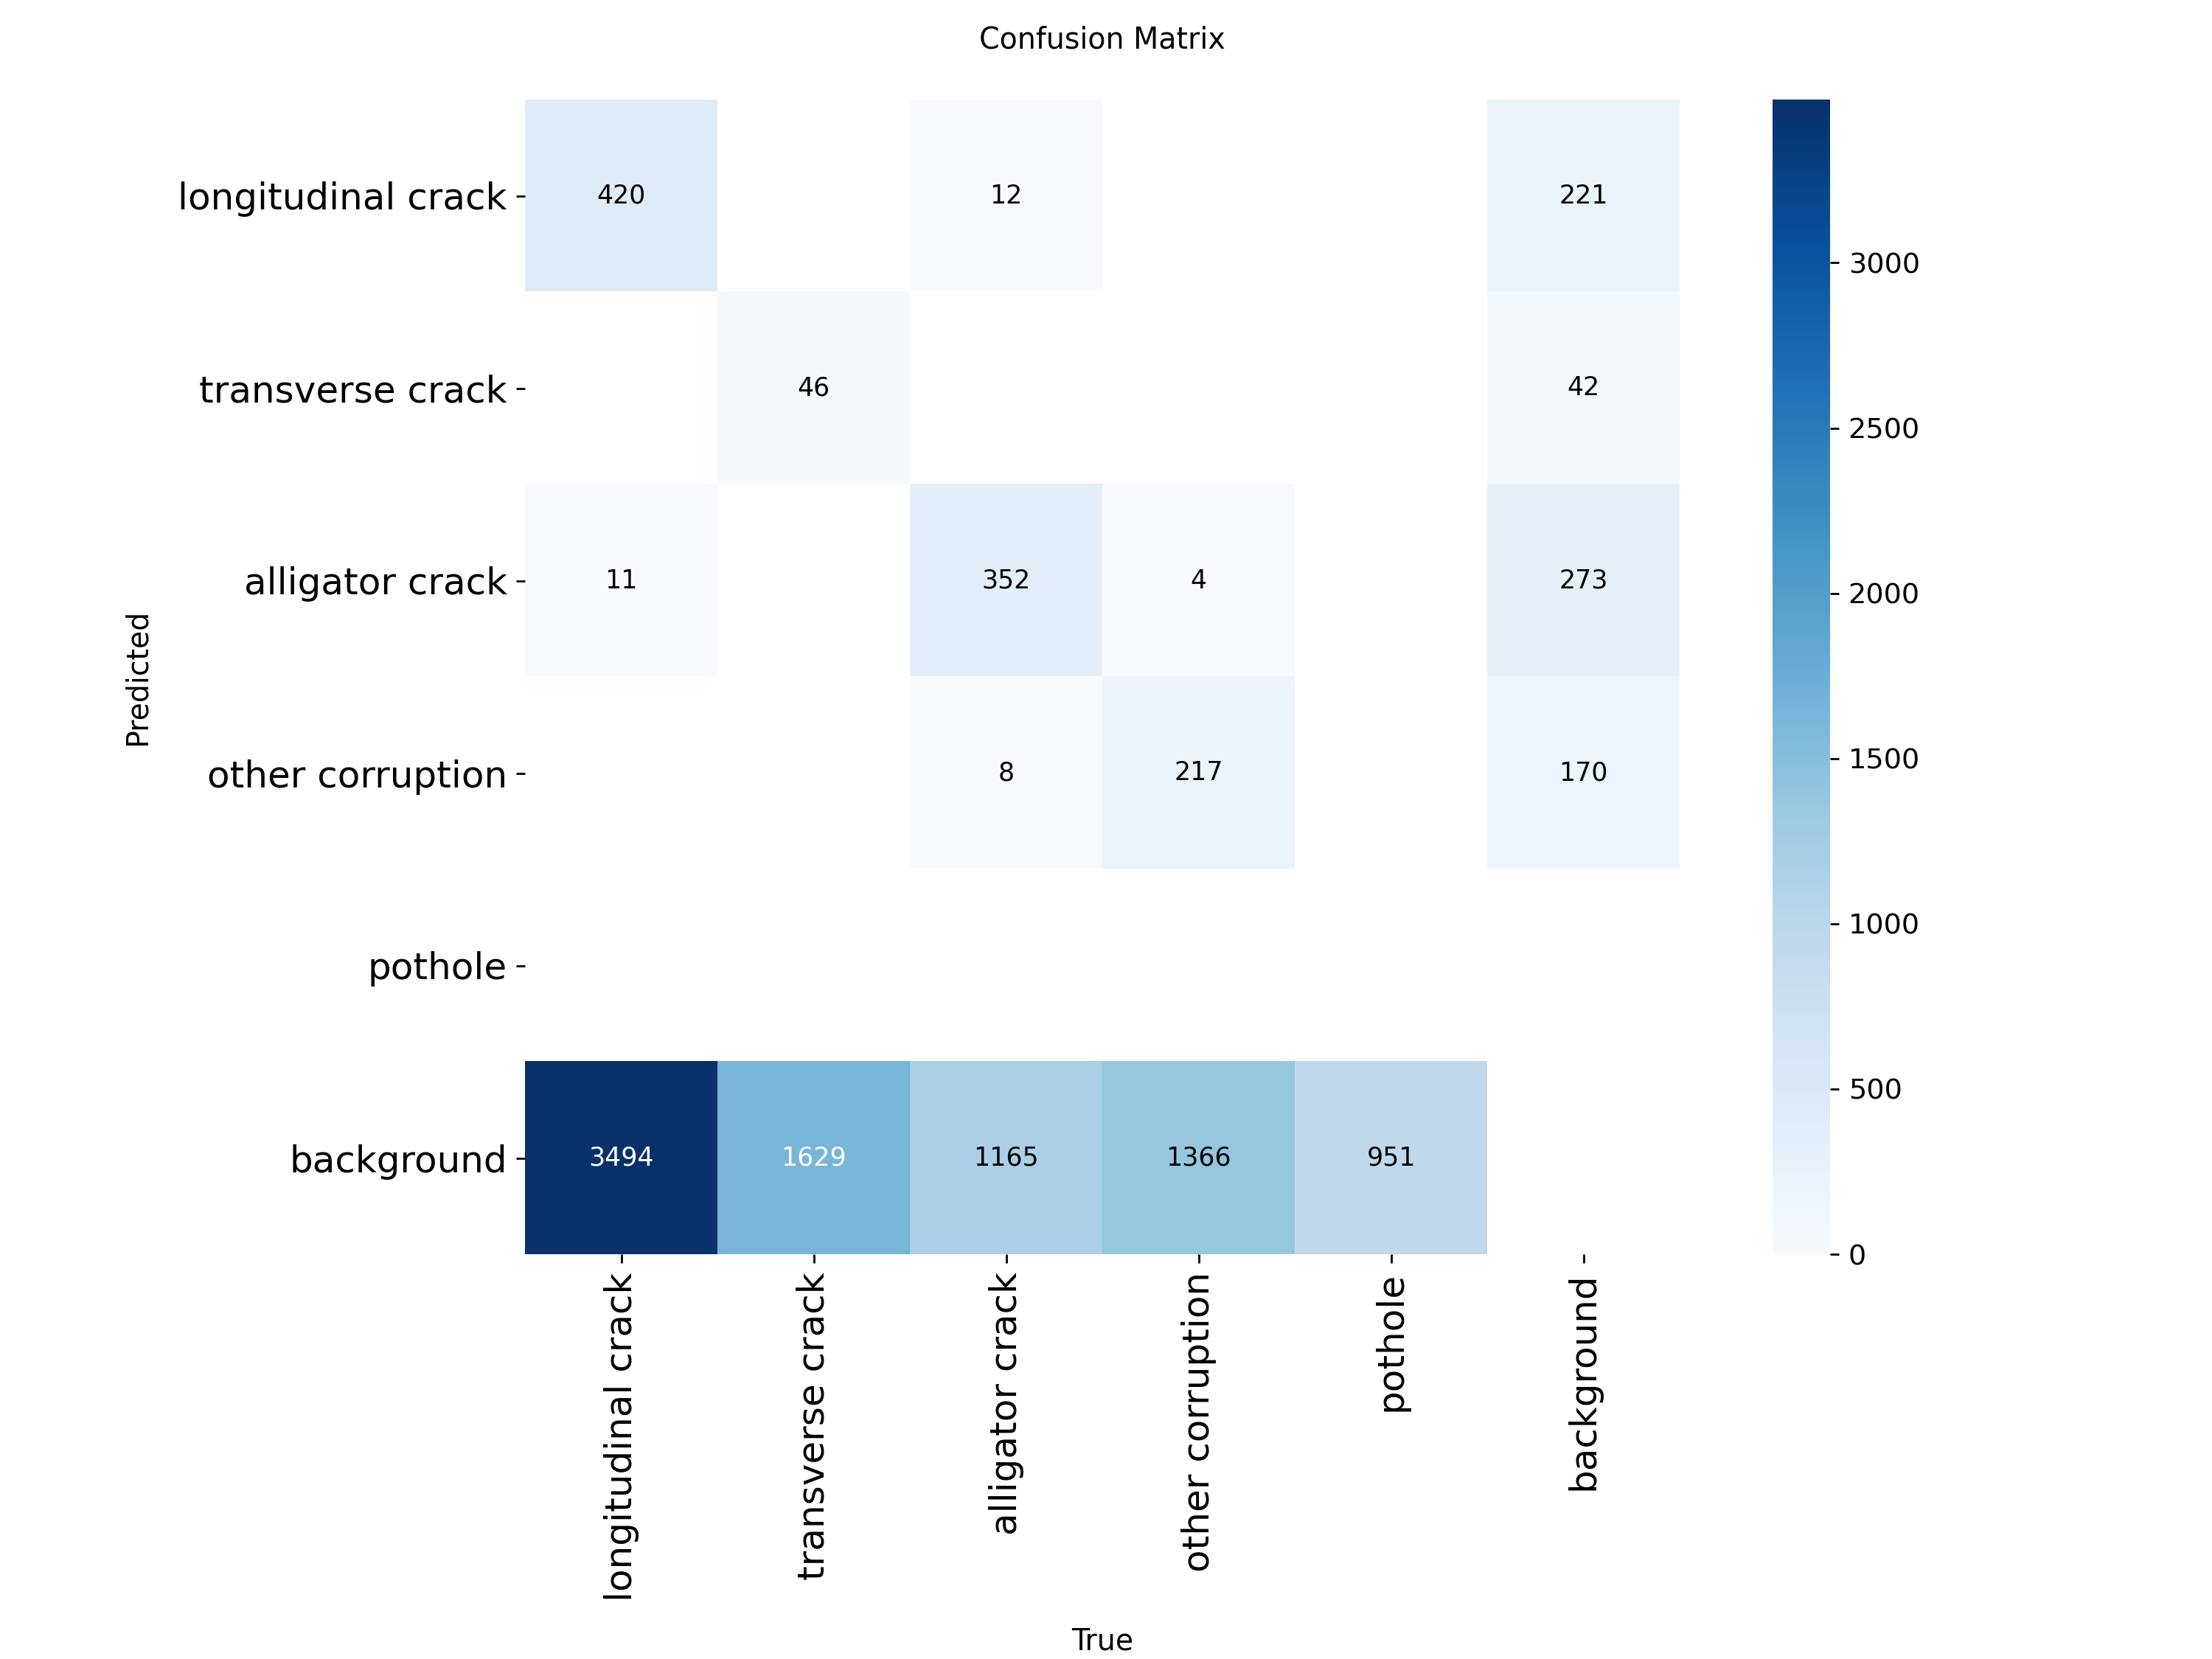

In [4]:
import yaml
print("\n" + "="*50)
print("Финальная оценка на TEST наборе...")
print("="*50)

test_metrics = model.val(split='test', save_json=False, verbose=False)

test_map50 = float(test_metrics.box.map50)
test_map50_95 = float(test_metrics.box.map)
test_prec = float(test_metrics.box.p.mean())
test_rec = float(test_metrics.box.r.mean())
test_f1 = float(test_metrics.box.f1.mean())

print(f"\nРезультаты:")
print(f"mAP@0.5     : {test_map50:.4f}")
print(f"mAP@0.5:0.95: {test_map50_95:.4f}")
print(f"Precision   : {test_prec:.4f}")
print(f"Recall      : {test_rec:.4f}")
print(f"F1-Score    : {test_f1:.4f}")

test_results = {
    "model": "YOLOv11n",
    "dataset": "RDD-2022",
    "split": "test",
    "metrics": {
        "mAP@0.5": round(test_map50, 4),
        "mAP@0.5:0.95": round(test_map50_95, 4),
        "Precision": round(test_prec, 4),
        "Recall": round(test_rec, 4),
        "F1": round(test_f1, 4)
    }
}

with open("custom_baseline_metrics.yaml", "w", encoding='utf-8') as f:
    yaml.dump(test_results, f, allow_unicode=True, default_flow_style=False)

print(f"\nТестовые метрики сохранены в: custom_baseline_metrics.yaml")


Финальная оценка на TEST наборе...
Ultralytics 8.4.40  Python-3.10.18 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 1183.2924.6 MB/s, size: 424.8 KB)
val: Scanning C:\Users\JonAJ\Desktop\RDD2022\RoadDamageDetection\RDD_SPLIT\test\labels.cache... 5758 images, 1790 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5758/5758  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 360/360 10.0it/s 35.8s0.1ss
                   all       5758       9675      0.275      0.202      0.146     0.0541
Speed: 1.1ms preprocess, 1.2ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to C:\Users\JonAJ\Desktop\RDD2022\RoadDamageDetection\runs\detect\val-8

Результаты:
mAP@0.5     : 0.1461
mAP@0.5:0.95: 0.0541
Precision   : 0.2754
Recall      : 0.2015
F1-Score    : 0.2091

Тестовые метрики сохранены в: custom_baseline_metrics.yaml


#### Выводы:

В результате обучения модели своей кастомной модели (custom_model.yaml), состоящей из 36 layers, 1,170,405 parameters, 1,170,389 gradients, были получены
результаты, которые сильно хуже чем у yolo11n. Во-первых это связано с тем, что моя модель является более простой и легковесной, а во-вторых при обучении на данных RDD2022 использовалась предобученая модель yolov11n.


|Результаты:  |       |
|-------------|-------|
|mAP@0.5      | 0.1461|
|mAP@0.5:0.95 | 0.0541|
|Precision    | 0.2754|
|Recall       | 0.2015|
|F1-Score     | 0.2091|

In [5]:
from ultralytics import YOLO
import pandas as pd
from pathlib import Path

DATA_CONFIG = "./data.yaml"
MODEL_NAME = "custom_model.yaml"
PROJECT_DIR = "test1"
EXP_NAME_IMPROVED = "improved_baseline_custom"

print(f"Проверка путей: {Path(DATA_CONFIG).absolute()}")

print(f"\nИнициализация модели: {MODEL_NAME}")
model = YOLO(MODEL_NAME)

print("\nНачинаем обучение (Baseline)...")
results = model.train(
    data=DATA_CONFIG,
    epochs=15,                    # H2
    imgsz=640,
    batch=16,
    seed=42,
    
    # H2: Оптимизация обучения
    optimizer='SGD',             
    lr0=0.005,                    
    lrf=0.01,                     
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3.0,
    
    # H1: Аугментации
    mosaic=1.0,                   
    mixup=0.0,                    
    degrees=0.0,                  
    translate=0.1,                
    scale=0.5,                    
    flipud=0.0,                   
    fliplr=0.5,                   
    hsv_h=0.015,                  
    hsv_s=0.7,                    
    hsv_v=0.4,                    
    
    # Управление обучением
    patience=10,                  
    save=True,
    save_period=5,  
    val=True,
    project=PROJECT_DIR,
    name=EXP_NAME_IMPROVED,
    exist_ok=True,
    pretrained=True,
    verbose=True,
    workers=4,
    amp=True,
)

print("\nЗапуск валидации (Оценка метрик)...")
metrics = model.val()

metric_dict = {
    "mAP@0.5": round(float(metrics.box.map50), 4),
    "mAP@0.5:0.95": round(float(metrics.box.map), 4),
    "Precision": round(float(metrics.box.p.mean()), 4),
    "Recall": round(float(metrics.box.r.mean()), 4),
    "F1-Score": round(float(metrics.box.f1.mean()), 4)
}

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ БАЗОВОЙ МОДЕЛИ")
print("="*50)
for k, v in metric_dict.items():
    print(f"{k:12} : {v}")
print("="*50)

df_metrics = pd.DataFrame([metric_dict])
df_metrics.to_csv("improved_baseline_custom.csv", index=False)
print(f"\nМетрики сохранены в: improved_baseline_custom.csv")
print(f"Веса модели: {PROJECT_DIR}/{EXP_NAME}/weights/best.pt")

Проверка путей: c:\Users\JonAJ\Desktop\RDD2022\RoadDamageDetection\data.yaml

Инициализация модели: custom_model.yaml

Начинаем обучение (Baseline)...
New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.40  Python-3.10.18 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_w

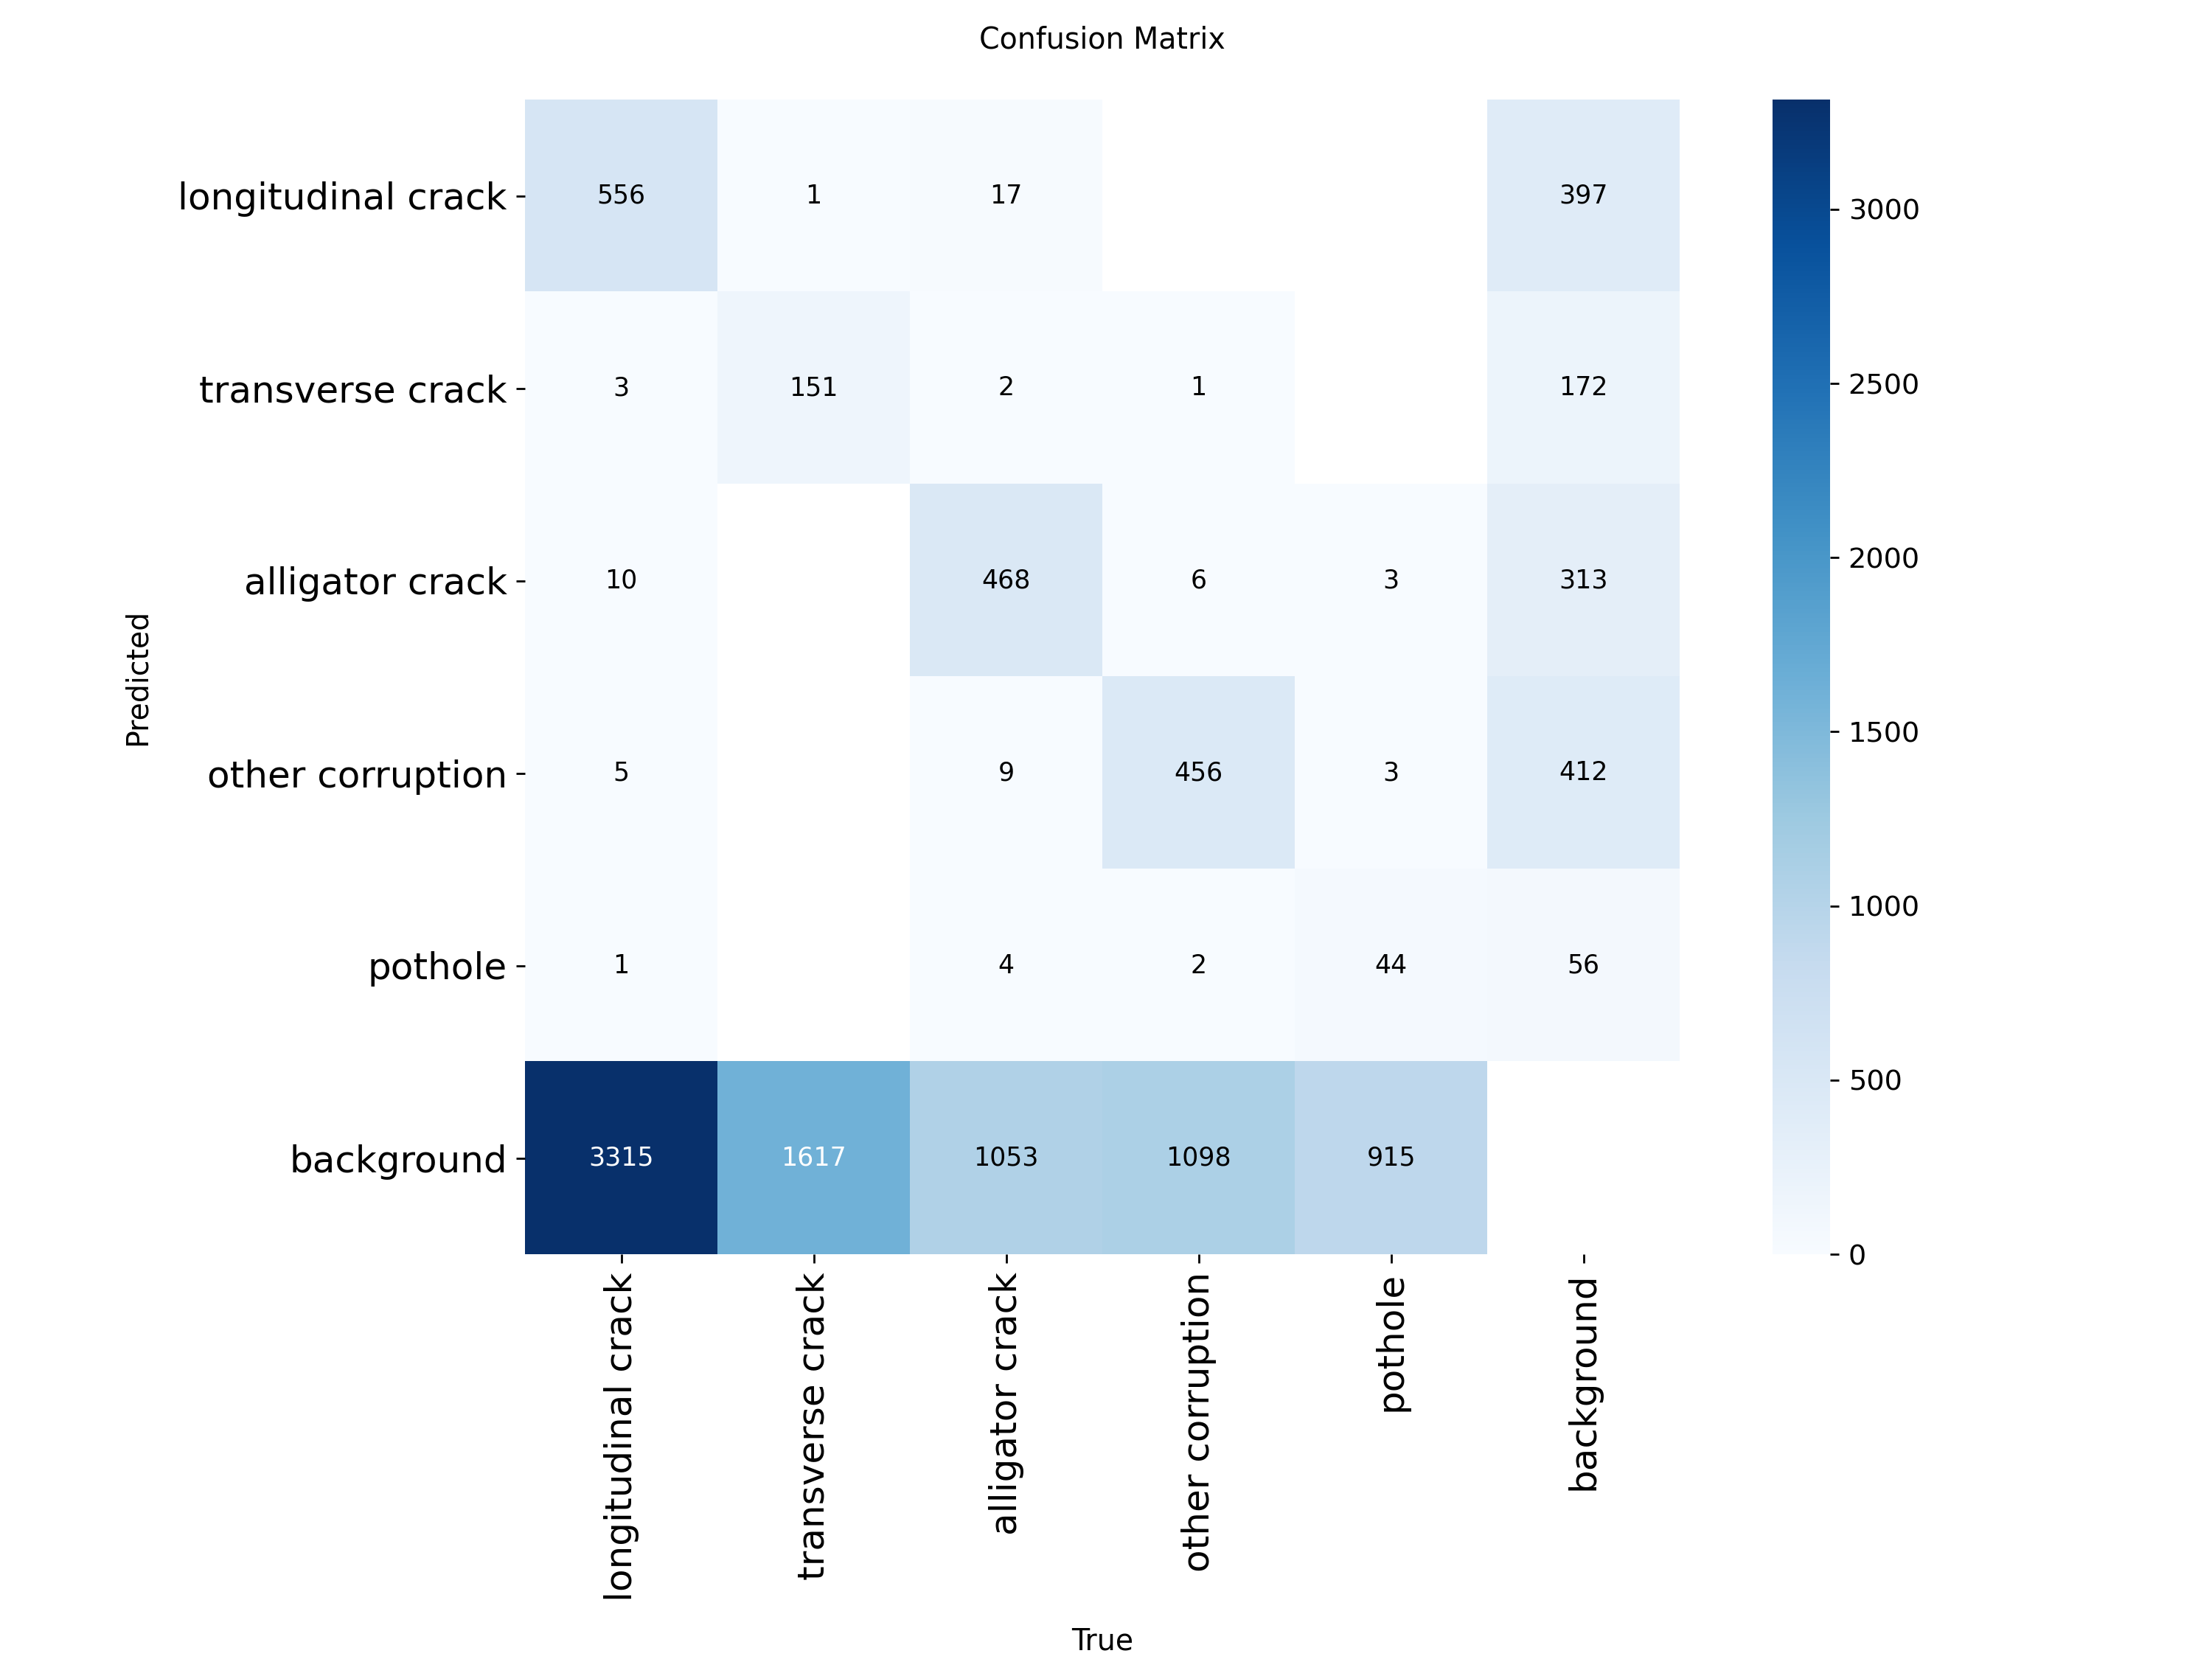

In [6]:
import yaml
print("\n" + "="*50)
print("Финальная оценка на TEST наборе...")
print("="*50)

test_metrics = model.val(split='test', save_json=False, verbose=False)

test_map50 = float(test_metrics.box.map50)
test_map50_95 = float(test_metrics.box.map)
test_prec = float(test_metrics.box.p.mean())
test_rec = float(test_metrics.box.r.mean())
test_f1 = float(test_metrics.box.f1.mean())

print(f"\nРезультаты:")
print(f"mAP@0.5     : {test_map50:.4f}")
print(f"mAP@0.5:0.95: {test_map50_95:.4f}")
print(f"Precision   : {test_prec:.4f}")
print(f"Recall      : {test_rec:.4f}")
print(f"F1-Score    : {test_f1:.4f}")

test_results = {
    "model": "YOLOv11n",
    "dataset": "RDD-2022",
    "split": "test",
    "metrics": {
        "mAP@0.5": round(test_map50, 4),
        "mAP@0.5:0.95": round(test_map50_95, 4),
        "Precision": round(test_prec, 4),
        "Recall": round(test_rec, 4),
        "F1": round(test_f1, 4)
    }
}

with open("custom_improved_baseline_metrics.yaml", "w", encoding='utf-8') as f:
    yaml.dump(test_results, f, allow_unicode=True, default_flow_style=False)

print(f"\nТестовые метрики сохранены в: custom_improved_baseline_metrics.yaml")


Финальная оценка на TEST наборе...
Ultralytics 8.4.40  Python-3.10.18 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 318.1386.8 MB/s, size: 347.1 KB)
val: Scanning C:\Users\JonAJ\Desktop\RDD2022\RoadDamageDetection\RDD_SPLIT\test\labels.cache... 5758 images, 1790 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5758/5758  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 360/360 8.3it/s 43.2s<0.1s
                   all       5758       9675      0.308       0.25      0.199     0.0774
Speed: 1.2ms preprocess, 1.6ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to C:\Users\JonAJ\Desktop\RDD2022\RoadDamageDetection\runs\detect\val-10

Результаты:
mAP@0.5     : 0.1992
mAP@0.5:0.95: 0.0774
Precision   : 0.3080
Recall      : 0.2501
F1-Score    : 0.2675

Тестовые метрики сохранены в: custom_improved_baseline_metrics.yaml


#### Выводы:

В результате обучения модели своей кастомной модели (custom_model.yaml) c немного улучшенным бейзлайном были получены результаты, которые сильно хуже чем у yolo11n. Во-первых это связано с тем, что моя модель является более простой и легковесной, а во-вторых при обучении на данных RDD2022 использовалась предобученая модель yolov11n.


|Результаты:  |       |
|-------------|-------|
|mAP@0.5      | 0.1992|
|mAP@0.5:0.95 | 0.0774|
|Precision    | 0.3080|
|Recall       | 0.2501|
|F1-Score     | 0.2675|

#### Сравнение всех результатов
| Metric | baseline_yolov11n | improved_baseline_yolov11n | baseline_custom | improved_baseline_custom |
|--------|------------------|---------------------------|-----------------|-------------------------|
| mAP@0.5 | 0.4847 | **0.5211** | 0.1461 | **0.1992** |
| mAP@0.5:0.95 | 0.2471 | **0.2708** | 0.0541 | **0.0774** |
| Precision | 0.5544 | **0.5837** | 0.2754 | **0.3080** |
| Recall | 0.4712 | **0.4985** | 0.2015 | **0.2501** |
| F1-Score | 0.5037 | **0.5335** | 0.2091 | **0.2675** |